In [2]:
import torch


model_color = torch.load(
    "/run/media/ki/data/mln-ood/gtsrb/models/wrn40/model-color-00000.pt"
)
model_shape = torch.load(
    "/run/media/ki/data/mln-ood/gtsrb/models/wrn40/model-shape-00000.pt"
)
model_label = torch.load(
    "/run/media/ki/data/mln-ood/gtsrb/models/wrn40/model-label-00000.pt"
)

In [3]:
textures_data = torch.load(
    "/run/media/ki/data/mln-ood/gtsrb/predictions/wrn40/data-Textures-00000.pt"
)

print(list(textures_data.keys()))
confidences, labels = textures_data["label-logits"].softmax(dim=1).max(dim=1)
_, colors = textures_data["color-logits"].softmax(dim=1).max(dim=1)
_, shapes = textures_data["shape-logits"].softmax(dim=1).max(dim=1)

['oe-logits', 'oe-features', 'shape-logits', 'shape-features', 'color-logits', 'color-features', 'label-logits', 'label-features', 'labels']


In [9]:
import matplotlib.pyplot as plt
from pytorch_ood.dataset.img import Textures
from dataset import GTSRB
from torchvision.transforms.functional import resize

# Enable LaTeX rendering in matplotlib
plt.rcParams.update(
    {
        "text.usetex": True,  # Use LaTeX to render text
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath, amssymb}",  # Load required packages,
        "pdf.fonttype": 42,  # Ensure fonts are stored as Type 42 (TrueType) for best quality in PDFs
        "ps.fonttype": 42,
        "text.usetex": True,  # Use LaTeX for text rendering
        "font.serif": ["Times"],  # Set Times as the default serif font
    }
)

#
# weights = torch.load('outputs/2024-09-07/14-10-38/oe-mln-1.pt')
# print(weights)

# Load the dataset
dataset = Textures("../data/")

# Assuming confidences is already defined
values, indices = confidences.topk(k=200)
values, indices = values[100:], indices[100:]

labels_str = [GTSRB.class_to_name[i.item()].title() for i in labels]
colors_str = [GTSRB.color_to_name[i.item()].title() for i in colors]
shapes_str = [GTSRB.shape_to_name[i.item()].title() for i in shapes]

# Create a plot
# fig, axes = plt.subplots(8, 5, figsize=(20, 20))

for idx, val in zip(indices, values):
    # Get the image and label from the dataset
    img, label = dataset[idx]

    fig, ax = plt.subplots(1, 1, figsize=(3, 3))

    # Plot the image
    ax.imshow(resize(img, (128, 128)))  # Assuming img is a tensor in CxHxW format
    p = "$\%$"
    ax.set_title(
        f"MSP Confidence: {val * 100:.1f} {p}\nLabel: {labels_str[idx]}\nShape: {shapes_str[idx]}\nColor: {colors_str[idx]}",
        loc="left",
    )  # , color='white'
    ax.axis("off")

    plt.tight_layout(pad=0)
    plt.savefig(
        f"/home/ki/tmp/tmpp/fig-{idx}.pdf", bbox_inches="tight", pad_inches=0, dpi=300
    )
    plt.close()
    # plt.show()

In [16]:
from pytorch_ood.dataset.img import iNaturalist

data = torch.load(
    "/run/media/ki/data/mln-ood/gtsrb/predictions/wrn40/data-iNaturalist-00000.pt"
)

print(list(data.keys()))
confidences, labels = data["label-logits"].softmax(dim=1).max(dim=1)
_, colors = data["color-logits"].softmax(dim=1).max(dim=1)
_, shapes = data["shape-logits"].softmax(dim=1).max(dim=1)

import matplotlib.pyplot as plt
from pytorch_ood.dataset.img import Textures
from dataset import GTSRB
from torchvision.transforms.functional import resize

# Enable LaTeX rendering in matplotlib
plt.rcParams.update(
    {
        "text.usetex": True,  # Use LaTeX to render text
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath, amssymb}",  # Load required packages,
        "pdf.fonttype": 42,  # Ensure fonts are stored as Type 42 (TrueType) for best quality in PDFs
        "ps.fonttype": 42,
        "text.usetex": True,  # Use LaTeX for text rendering
        "font.serif": ["Times"],  # Set Times as the default serif font
    }
)

#
# weights = torch.load('outputs/2024-09-07/14-10-38/oe-mln-1.pt')
# print(weights)

# Load the dataset
dataset = iNaturalist("../data/")

# Assuming confidences is already defined
values, indices = confidences.topk(k=200)
values, indices = values[100:], indices[100:]

labels_str = [GTSRB.class_to_name[i.item()].title() for i in labels]
colors_str = [GTSRB.color_to_name[i.item()].title() for i in colors]
shapes_str = [GTSRB.shape_to_name[i.item()].title() for i in shapes]

# Create a plot
# fig, axes = plt.subplots(8, 5, figsize=(20, 20))

for idx, val in zip(indices, values):
    # Get the image and label from the dataset
    img, label = dataset[idx]

    fig, ax = plt.subplots(1, 1, figsize=(3, 3))

    # Plot the image
    ax.imshow(resize(img, (128, 128)))  # Assuming img is a tensor in CxHxW format
    p = "$\%$"
    ax.set_title(
        f"MSP Confidence: {val * 100:.1f} {p}\nLabel: {labels_str[idx]}\nShape: {shapes_str[idx]}\nColor: {colors_str[idx]}",
        loc="left",
    )  # , color='white'
    ax.axis("off")

    plt.tight_layout(pad=0)
    plt.savefig(
        f"/home/ki/tmp/tmpp/fig-{idx}.jpg", bbox_inches="tight", pad_inches=0, dpi=300
    )
    plt.close()
    # plt.show()

['oe-logits', 'oe-features', 'shape-logits', 'shape-features', 'color-logits', 'color-features', 'label-logits', 'label-features', 'labels']


96


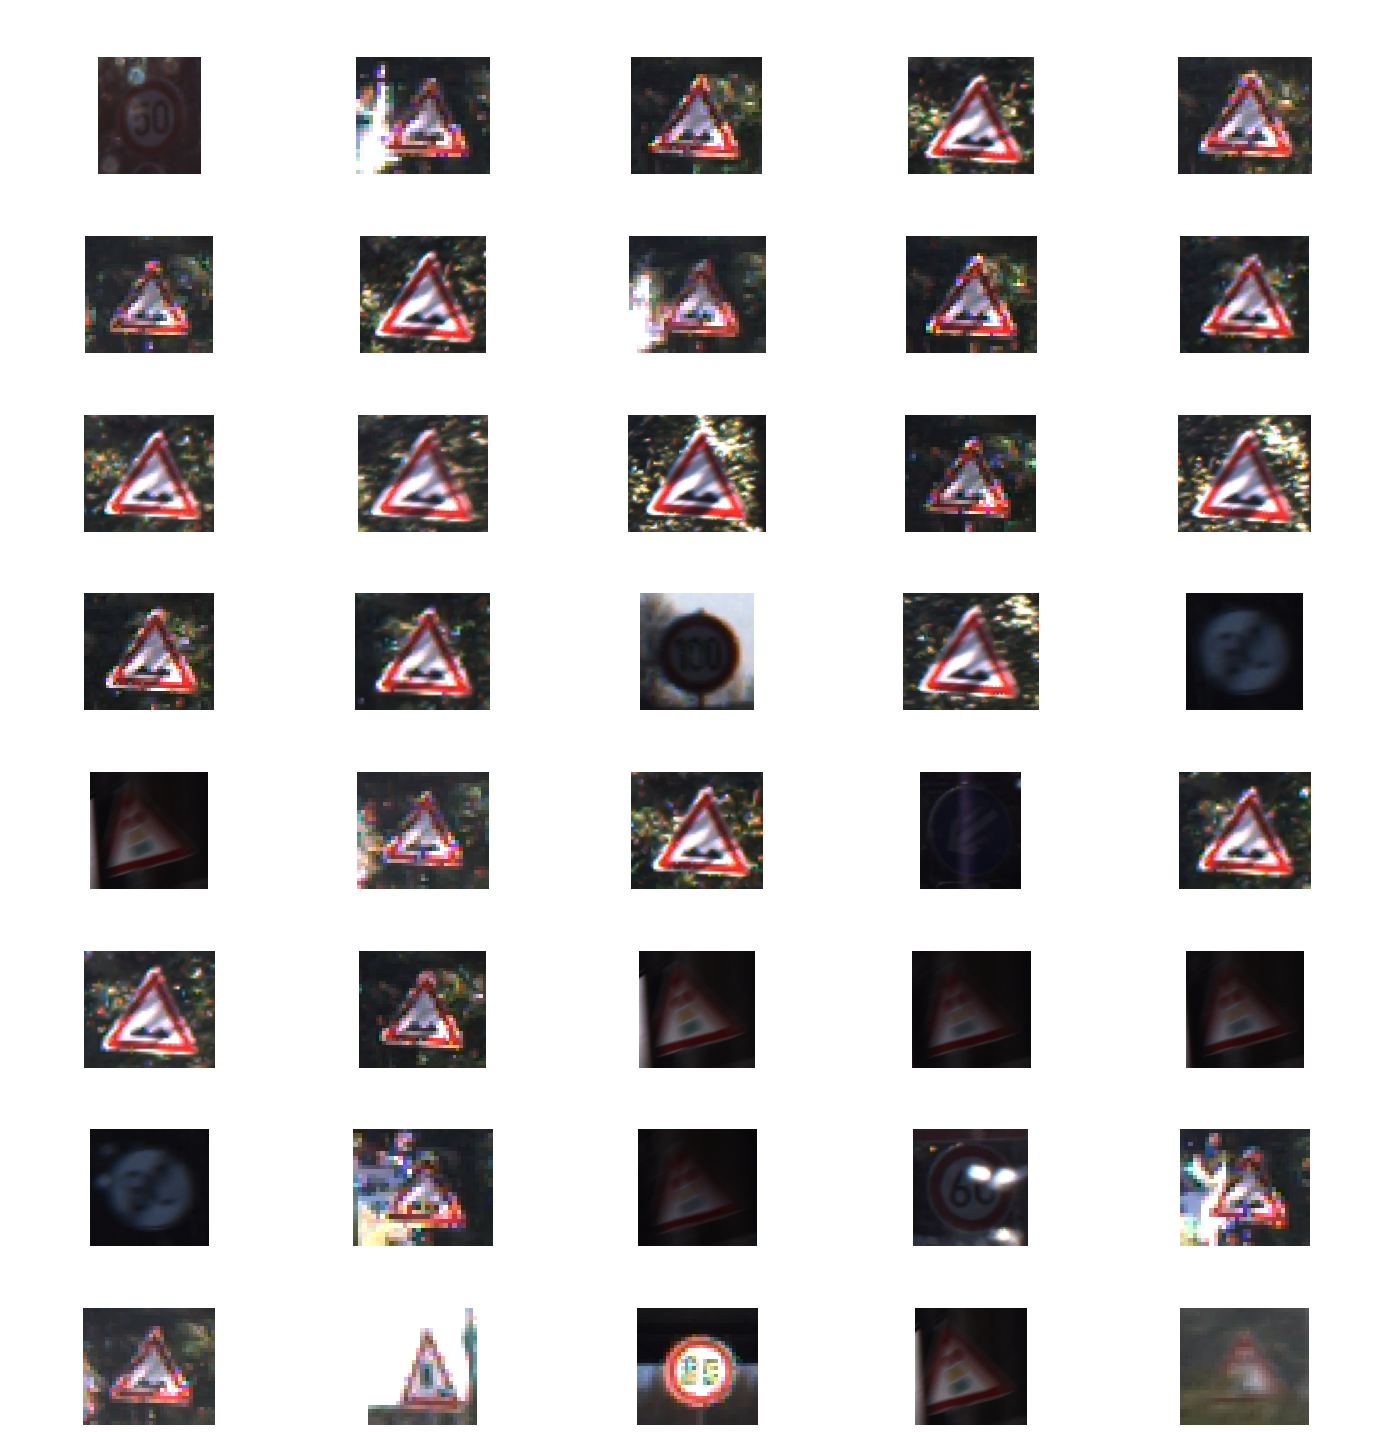

In [13]:
data = torch.load(
    "/run/media/ki/data/mln-ood/gtsrb/predictions/wrn40/data-test-00000.pt"
)

print(list(data.keys()))
conf_labels, labels = data["label-logits"].softmax(dim=1).max(dim=1)
conf_colors, colors = data["color-logits"].softmax(dim=1).max(dim=1)
conf_shapes, shapes = data["shape-logits"].softmax(dim=1).max(dim=1)

true_labels = data["labels"][:, 0]

import matplotlib.pyplot as plt
from pytorch_ood.dataset.img import Textures
from dataset import GTSRB

# Load the dataset
dataset = GTSRB("../data/", train=False)

filtr = labels != true_labels

# Assuming confidences is already defined
values, indices = conf_labels[filtr].topk(k=40)

labels_str = [GTSRB.class_to_name[i.item()] for i in labels[filtr]]
true_labels_str = [GTSRB.class_to_name[i.item()] for i in true_labels[filtr]]
colors_str = [GTSRB.color_to_name[i.item()] for i in colors[filtr]]
shapes_str = [GTSRB.shape_to_name[i.item()] for i in shapes[filtr]]

filter_idx = torch.arange(len(dataset))[filtr]
print(len(filter_idx))

# Create a plot
fig, axes = plt.subplots(8, 5, figsize=(20, 20))

for ax, idx, val in zip(axes.flatten(), indices, values):
    # Get the image and label from the dataset
    img, label = dataset[filter_idx[idx]]

    # Plot the image
    ax.imshow(img)  # Assuming img is a tensor in CxHxW format
    s = f"Conf: {val:.2f}\n{labels_str[idx]}[{true_labels_str[idx]}] ({conf_labels[filtr][idx]:.1%})\n{shapes_str[idx]} ({conf_shapes[filtr][idx]:.1%})\n{colors_str[idx]} ({conf_colors[filtr][idx]:.1%})"
    ax.set_title(s, color="white")
    ax.axis("off")

plt.tight_layout()
plt.savefig("/home/ki/traffic_sign.png")
plt.show()

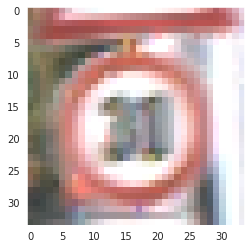

In [61]:
import numpy as np

plt.imshow(np.array(GTSRB("../data/")[1000][0].convert("RGBA")))
plt.grid(False)
plt.savefig("/home/ki/traffic_sign.png")

In [1]:
import torch

textures_data = torch.load(
    "/run/media/ki/data/mln-ood/gtsrb/predictions/data-Textures-00000.pt"
)

print(list(textures_data.keys()))
confidences, labels = textures_data["label-logits"].softmax(dim=1).max(dim=1)
_, colors = textures_data["color-logits"].softmax(dim=1).max(dim=1)
_, shapes = textures_data["shape-logits"].softmax(dim=1).max(dim=1)

['shape-logits', 'shape-features', 'color-logits', 'color-features', 'label-logits', 'label-features', 'labels', 'eo-logits', 'eo-features']


In [3]:
import torch
from mln import SimpleMLN
from gtsrb_rules import rule_fn

In [6]:
mln = SimpleMLN(constraints=rule_fn)


def energy(x):
    e = torch.zeros(size=(x.shape[0], 1), device=x.device)
    for i, f in enumerate(rule_fn):
        fx = f(x)
        e += fx * 1

    print(e)
    # https://gregorygundersen.com/blog/2020/02/09/log-sum-exp/
    max_e = torch.max(e)
    e_stable = e - max_e
    e_exp = e_stable.exp()
    e_final = e_exp.log() + max_e
    return e_final.exp().squeeze()


from gtsrb import GTSRB

# label: 0
# color: 1
# shape: 2
# oe: 3

n_classes = len(GTSRB.color_to_name)

with torch.no_grad():
    for i in range(n_classes):
        x = torch.tensor([13, i, 4]).unsqueeze(0)
        r = mln.prob(x)
        print(f"class {GTSRB.color_to_name[i]} {i}:\t{r.item()}")

        s = []
        for rule in rule_fn:
            s.append(rule(x).item())

        print(rule_fn[13].__name__, rule_fn[13](x))
        print(sum(s))

class red 0:	0.0011890606256201863
f_stop tensor([[1.]])
43.0
class blue 1:	0.0011614080285653472
f_stop tensor([[0.]])
42.0
class yellow 2:	0.0011614080285653472
f_stop tensor([[0.]])
42.0
class white 3:	0.0011614080285653472
f_stop tensor([[0.]])
42.0


In [10]:
GTSRB.shape_to_name

{0: 'triangle', 1: 'circle', 2: 'square', 4: 'octagon', 3: 'inverse triangle'}

In [11]:
GTSRB.color_to_name

{0: 'red', 1: 'blue', 2: 'yellow', 3: 'white'}

In [9]:
def f_stop(x: torch.Tensor) -> torch.Tensor:
    sat = (x[:, 1] == 0) & (x[:, 2] == 4)
    a = torch.ones(size=(x.shape[0],), device=x.device)
    b = torch.zeros(size=(x.shape[0],), device=x.device)
    return torch.where((x[:, 0] == 13) & ~sat, b, a).unsqueeze(1)

In [7]:
for i in range(n_classes):
    x = torch.tensor([13, i, 4]).unsqueeze(0)
    print(f_stop(x))

tensor([[1.]])
tensor([[0.]])
tensor([[0.]])
tensor([[0.]])


In [24]:
GTSRB.class_to_name

{0: 'speed limit 20',
 1: 'speed limit 30',
 2: 'speed limit 50',
 3: 'speed limit 60',
 4: 'speed limit 70',
 5: 'speed limit 80',
 6: 'restriction ends 80',
 7: 'speed limit 100',
 8: 'speed limit 120',
 9: 'no overtaking',
 10: 'no overtaking trucks',
 11: 'priority at next intersection',
 12: 'priority road',
 13: 'give way',
 14: 'stop',
 15: 'no traffic both ways',
 16: 'no trucks',
 17: 'no entry',
 18: 'danger',
 19: 'bend left',
 20: 'bend right',
 21: 'bend',
 22: 'uneven road',
 23: 'slippery road',
 24: 'road narrows',
 25: 'construction',
 26: 'traffic signal',
 27: 'pedestrian crossing',
 28: 'school crossing',
 29: 'cycles crossing',
 30: 'snow',
 31: 'animals',
 32: 'restriction ends',
 33: 'go right',
 34: 'go left',
 35: 'go straight',
 36: 'go right or straight',
 37: 'go left or straight',
 38: 'keep right',
 39: 'keep left',
 40: 'roundabout',
 41: 'restriction ends overtaking',
 42: 'restriction ends overtaking trucks'}

In [11]:
print(rule_fn[13].__name__)

f_stop
